# Antartica project 2026
**Antarctic Ross Sea-Ice Thickness Variability and Its Relationship with Southern Ocean Ocean Heat**

- **Question:**
*How does Antarctic Ross sea-ice thickness vary on seasonal and interannual timescales, and to what extent is this variability associated with changes in ocean temperature and heat content?*

- **Data:**
ORAS5, 2015–2025/2026

In [23]:
# Packages
import pandas as pd
import numpy as np
import xarray as xr
import os

import matplotlib.pyplot as plt

## Exploratory Data Analysis

**Data shape**

In [126]:
#Concat all NetCDF files
prefixes = ["iicethic", "sohtc300", "sosstsst"]
da_by_prefix = {}

for prefixe in prefixes:
    print(prefixe)
    files = []

    for year in range(2015, 2027):

        max_month = 12 if year < 2026 else 8

        for month in range(1, max_month + 1):

            file_path = (
                f"C:\\Users\\l.ruizlozano\\Documents\\Antartica-project\\"
                f"data\\ORAS5\\"
                f"{prefixe}_control_monthly_highres_2D_"
                f"{year}{month:02d}_OPER_v0.1.nc"
            )

            if os.path.exists(file_path):
                files.append(file_path)

    ds_all = xr.open_mfdataset(
        files,
        combine="by_coords"
    )
    da_by_prefix[prefixe] = ds_all

iicethic


C:\Users\l.ruizlozano\AppData\Local\Temp\ipykernel_9352\868470652.py:25: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time_counter' ('time_counter',) The recommendation is to set join explicitly for this case.
  ds_all = xr.open_mfdataset(
C:\Users\l.ruizlozano\AppData\Local\Temp\ipykernel_9352\868470652.py:25: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_all = xr.open_mfdataset(
C:\Users\l.ruizlozano\AppData\Local\Te

sohtc300


C:\Users\l.ruizlozano\AppData\Local\Temp\ipykernel_9352\868470652.py:25: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time_counter' ('time_counter',) The recommendation is to set join explicitly for this case.
  ds_all = xr.open_mfdataset(
C:\Users\l.ruizlozano\AppData\Local\Temp\ipykernel_9352\868470652.py:25: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_all = xr.open_mfdataset(
C:\Users\l.ruizlozano\AppData\Local\Te

sosstsst


C:\Users\l.ruizlozano\AppData\Local\Temp\ipykernel_9352\868470652.py:25: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time_counter' ('time_counter',) The recommendation is to set join explicitly for this case.
  ds_all = xr.open_mfdataset(
C:\Users\l.ruizlozano\AppData\Local\Temp\ipykernel_9352\868470652.py:25: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_all = xr.open_mfdataset(
C:\Users\l.ruizlozano\AppData\Local\Te

da_by_prefix
│
├── "iicethic" → sea ice thickness xarray
├── "sohtc300" → ocean heat xarray
└── "sosstsst" → SST xarray

In [127]:
# Ross Sea: region of interest 
lat_min, lat_max = -76, -74
lon_min, lon_max = 174, 176

roi_dfs = {}

for prefix, ds in da_by_prefix.items():

    mask = (
        (ds["nav_lat"] >= lat_min) &
        (ds["nav_lat"] <= lat_max) &
        (ds["nav_lon"] >= lon_min) &
        (ds["nav_lon"] <= lon_max)
    )

    ds_roi = ds.where(mask.compute(), drop=True)

    roi_dfs[prefix] = ds_roi

- Sea ice thickness

In [128]:
df_sit = (roi_dfs["iicethic"][["nav_lon","nav_lat","iicethic"]].to_dataframe().reset_index())
df_sit = df_sit.rename(columns={
    "time_counter": "time",
    "nav_lat": "lat",
    "nav_lon": "lon"
})
df_sit = df_sit[["time", "lon","lat","iicethic"]]

In [129]:
print('--- Shape---')
print(df_sit.shape)
print(' ')
print('--- Info---')
print(df_sit.info())
print(' ')
print('---NaN values---')
print(df_sit.isna().sum())

--- Shape---
(38781, 4)
 
--- Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38781 entries, 0 to 38780
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time      38781 non-null  datetime64[ns]
 1   lon       38781 non-null  float32       
 2   lat       38781 non-null  float32       
 3   iicethic  38781 non-null  float32       
dtypes: datetime64[ns](1), float32(3)
memory usage: 757.6 KB
None
 
---NaN values---
time        0
lon         0
lat         0
iicethic    0
dtype: int64


- Ocean heat

In [130]:
df_oh = (roi_dfs["sohtc300"][["nav_lon","nav_lat","sohtc300"]].to_dataframe().reset_index())
df_oh = df_oh.rename(columns={
    "time_counter": "time",
    "nav_lat": "lat",
    "nav_lon": "lon"
})
df_oh = df_oh[["time", "lon","lat","sohtc300"]]

In [131]:
print('--- Shape---')
print(df_oh.shape)
print(' ')
print('--- Info---')
print(df_oh.info())
print(' ')
print('---NaN values---')
print(df_oh.isna().sum())

--- Shape---
(38781, 4)
 
--- Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38781 entries, 0 to 38780
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time      38781 non-null  datetime64[ns]
 1   lon       38781 non-null  float32       
 2   lat       38781 non-null  float32       
 3   sohtc300  38781 non-null  float32       
dtypes: datetime64[ns](1), float32(3)
memory usage: 757.6 KB
None
 
---NaN values---
time        0
lon         0
lat         0
sohtc300    0
dtype: int64


- Sea surface temperature

In [132]:
df_sst = (roi_dfs["sosstsst"][["nav_lon","nav_lat","sosstsst"]].to_dataframe().reset_index())
df_sst = df_sst.rename(columns={
    "time_counter": "time",
    "nav_lat": "lat",
    "nav_lon": "lon"
})
df_sst = df_sst[["time", "lon","lat","sosstsst"]]

In [133]:
print('--- Shape---')
print(df_sst.shape)
print(' ')
print('--- Info---')
print(df_sst.info())
print(' ')
print('---NaN values---')
print(df_sst.isna().sum())

--- Shape---
(38781, 4)
 
--- Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38781 entries, 0 to 38780
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time      38781 non-null  datetime64[ns]
 1   lon       38781 non-null  float32       
 2   lat       38781 non-null  float32       
 3   sosstsst  38781 non-null  float32       
dtypes: datetime64[ns](1), float32(3)
memory usage: 757.6 KB
None
 
---NaN values---
time        0
lon         0
lat         0
sosstsst    0
dtype: int64


**Data content**

In [134]:
# Merge the 3 DataFrames: df gives the time, the coordinates, the sea ice thickness [m], the sea surface temperature [°C] and the ocean heat [J/m²]
df = pd.merge(pd.merge(df_sit, df_sst, on=["time", "lon", "lat"]), df_oh, on =["time", "lon", "lat"])
df = df.rename(columns={
    "iicethic": "sea ice thick",
    "sosstsst": "sea surface temp",
    "sohtc300": "ocean heat"
})
df.head()

,time,lon,lat,sea ice thick,sea surface temp,ocean heat
0,2015-01-16,174.0,-75.959343,0.000000,0.577931,-1.516163e+09
1,2015-02-15,174.0,-75.959343,0.027109,-0.900055,-1.503449e+09
2,2015-03-16,174.0,-75.959343,0.551697,-1.761970,-1.591986e+09
3,2015-04-16,174.0,-75.959343,0.715715,-1.739402,-1.593836e+09
4,2015-05-16,174.0,-75.959343,0.627804,-1.664265,-1.764333e+09


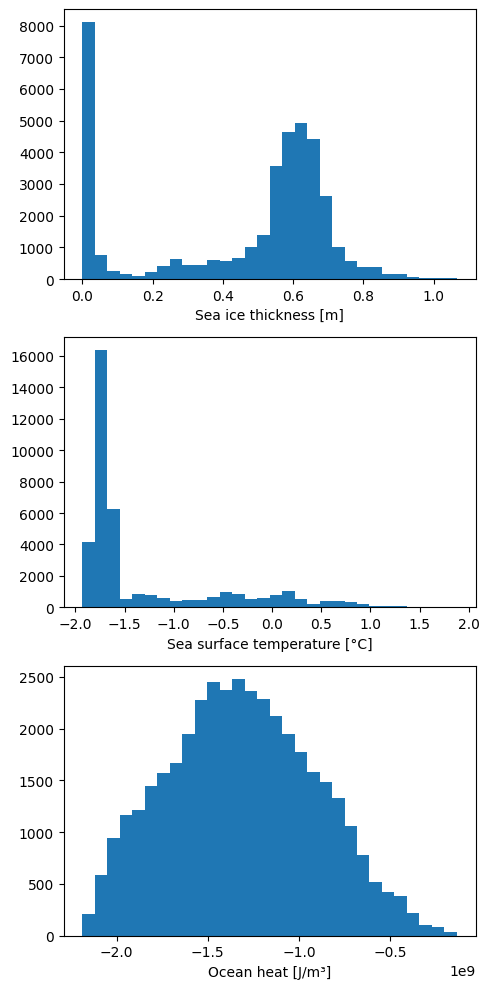

In [135]:
# Distribution of the target and features 
fig, axes = plt.subplots(3, 1, figsize=(5, 10), sharex=False)

# 1.
axes[0].hist(df["sea ice thick"], bins=30)
axes[0].set_xlabel("Sea ice thickness [m]")

# 2.
axes[1].hist(df["sea surface temp"], bins=30)
axes[1].set_xlabel("Sea surface temperature [°C]")

# 3. 
axes[2].hist(df["ocean heat"], bins=30)
axes[2].set_xlabel("Ocean heat [J/m³]")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Relation sea ice thickness-sea surface temperature')

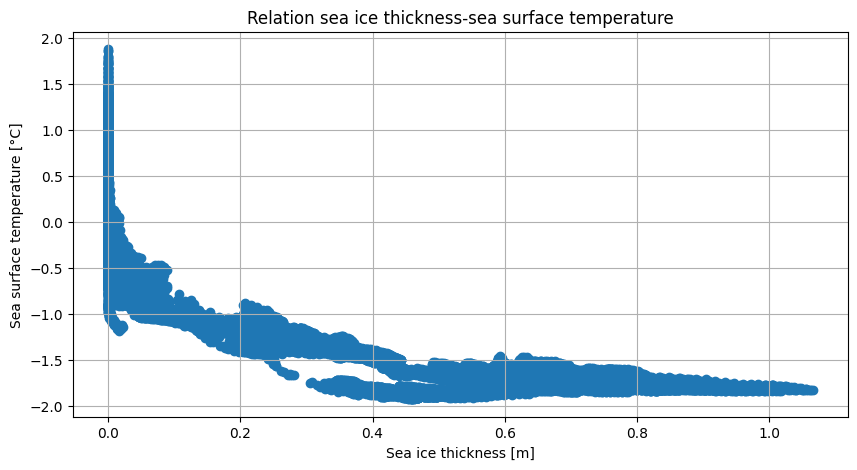

In [136]:
# Visualisation target-feature
plt.figure(figsize=(10,5))
plt.scatter(df["sea ice thick"], df["sea surface temp"])
plt.grid()
plt.xlabel("Sea ice thickness [m]"), plt.ylabel("Sea surface temperature [°C]")
plt.title("Relation sea ice thickness-sea surface temperature")

As expected, the graph shows that the two variables are inversely proportional at a certain point (sit ~ 0.4m), then it reaches a plateau around -1.5 and -2°C. 

Text(0.5, 1.0, 'Relation sea surface temperature-ocean heat')

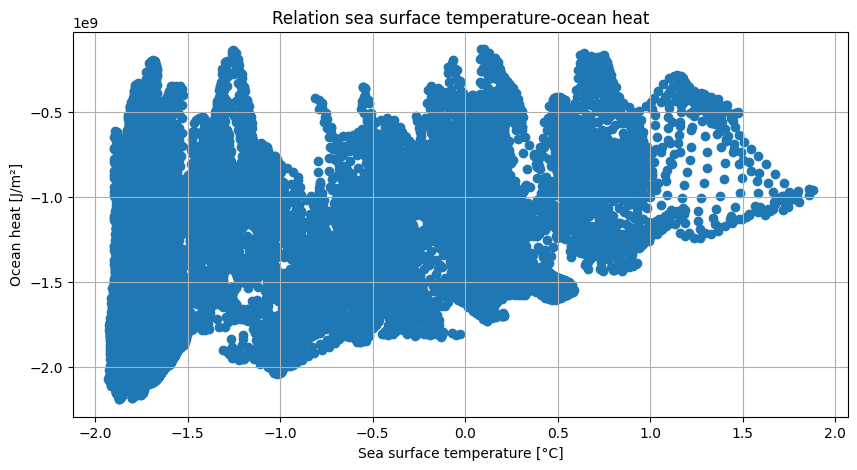

In [137]:
plt.figure(figsize=(10,5))
plt.scatter(df["sea surface temp"], df["ocean heat"])
plt.grid()
plt.xlabel("Sea surface temperature [°C]"), plt.ylabel("Ocean heat [J/m²]")
plt.title("Relation sea surface temperature-ocean heat")

Less obvious than the precedent plot but this graph shows a upward trend between the two features

- Spatial maps

In [52]:
import colormaps as cmaps
from matplotlib.patches import Rectangle

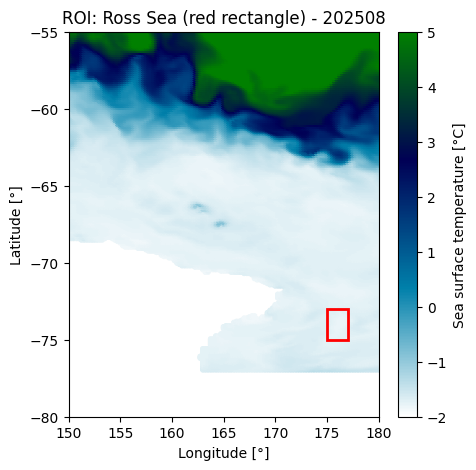

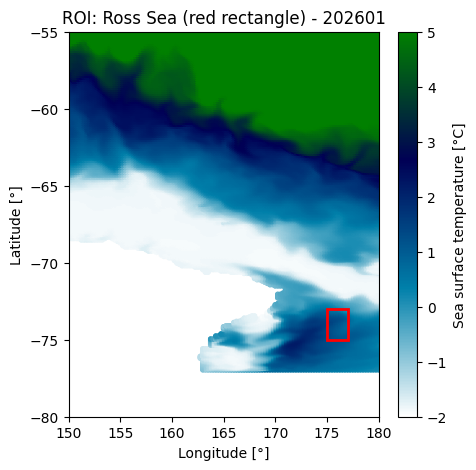

In [ ]:
urls = [r'C:\Users\l.ruizlozano\Documents\Antartica-project\data\ORAS5\sosstsst_control_monthly_highres_2D_202508_OPER_v0.1.nc',
        r'C:\Users\l.ruizlozano\Documents\Antartica-project\data\ORAS5\sosstsst_control_monthly_highres_2D_202601_OPER_v0.1.nc']

for url in urls:
    ds = xr.open_dataset(url)
    df_ = ds.to_dataframe().reset_index() 


    cmap = cmaps.ocean_r

    fig, ax = plt.subplots(figsize=(8,5))

    sc = ax.scatter(
        df_["nav_lon"],
        df_["nav_lat"],
        c=df_["sosstsst"],
        cmap=cmap,
        s=8,
        vmin=-2,
        vmax=5
    )

    # ROI: Ross sea
    # lat_min, lat_max = -76, -74
    # lon_min, lon_max = 174, 176
    ax.add_patch(Rectangle(
        xy=(175, -75) ,width=2, height=2,
        linewidth=2, color='red', fill=False))

    plt.title(f'ROI: Ross Sea (red rectangle) - {url.split('_')[-3]}')
    plt.xlabel("Longitude [°]"), plt.ylabel("Latitude [°]")
    plt.colorbar(sc, label="Sea surface temperature [°C]")
    plt.xlim([150,180]), ax.set_ylim([-80,-55])
    plt.show()

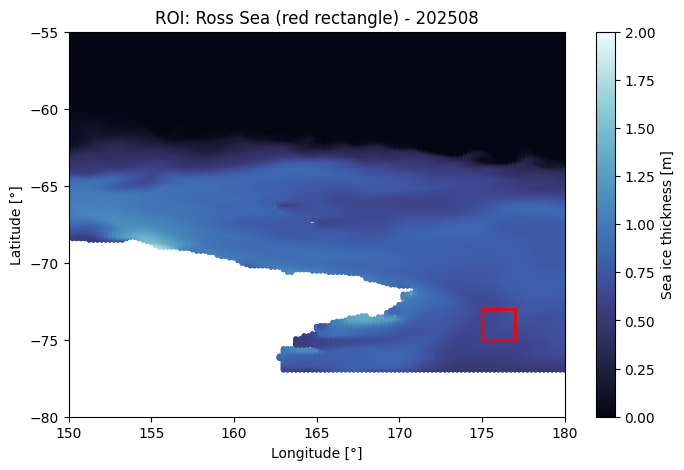

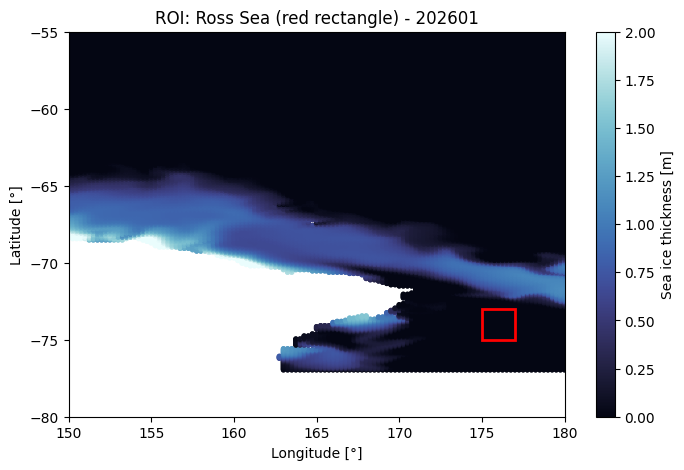

In [66]:
urls = [r'C:\Users\l.ruizlozano\Documents\Antartica-project\data\ORAS5\iicethic_control_monthly_highres_2D_202508_OPER_v0.1.nc',
        r'C:\Users\l.ruizlozano\Documents\Antartica-project\data\ORAS5\iicethic_control_monthly_highres_2D_202601_OPER_v0.1.nc']

for url in urls:
    ds = xr.open_dataset(url)
    df_ = ds.to_dataframe().reset_index() 


    cmap = cmaps.ice #.discrete(11).cut(0.25, 'left')

    fig, ax = plt.subplots(figsize=(8,5))

    sc = ax.scatter(
        df_["nav_lon"],
        df_["nav_lat"],
        c=df_["iicethic"],
        cmap=cmap,
        s=8,
        vmin=0,
        vmax=2
    )

    # ROI: Ross sea
    # lat_min, lat_max = -76, -74
    # lon_min, lon_max = 174, 176
    ax.add_patch(Rectangle(
        xy=(175, -75) ,width=2, height=2,
        linewidth=2, color='red', fill=False))

    plt.title(f'ROI: Ross Sea (red rectangle) - {url.split('_')[-3]}')
    plt.xlabel("Longitude [°]"), plt.ylabel("Latitude [°]")
    plt.colorbar(sc, label="Sea ice thickness [m]")
    plt.xlim([150,180]), ax.set_ylim([-80,-55])
    plt.show()
  

## Pre-processing

- Add time columns for better visualisation in the next section

In [138]:
df["date"] = df.time.dt.strftime('%Y-%m')
df["year"] = df.time.dt.year
df["month"] = df.time.dt.month

df["season"] = pd.cut(
    df["month"],
    bins=[0, 3, 6, 9, 12],
    labels=["summer","autumn","winter", "spring"]
)

In [140]:
df.head()

,time,lon,lat,sea ice thick,sea surface temp,ocean heat,date,year,month,season
0,2015-01-16,174.0,-75.959343,0.000000,0.577931,-1.516163e+09,2015-01,2015,1,summer
1,2015-02-15,174.0,-75.959343,0.027109,-0.900055,-1.503449e+09,2015-02,2015,2,summer
2,2015-03-16,174.0,-75.959343,0.551697,-1.761970,-1.591986e+09,2015-03,2015,3,summer
3,2015-04-16,174.0,-75.959343,0.715715,-1.739402,-1.593836e+09,2015-04,2015,4,autumn
4,2015-05-16,174.0,-75.959343,0.627804,-1.664265,-1.764333e+09,2015-05,2015,5,autumn


## Sea-ice climatology and variability

In this section, we investigate: 
- monthly climatology
- annual variability
- seasonal variability
- anomalies
- trend

**Monthly climatology**

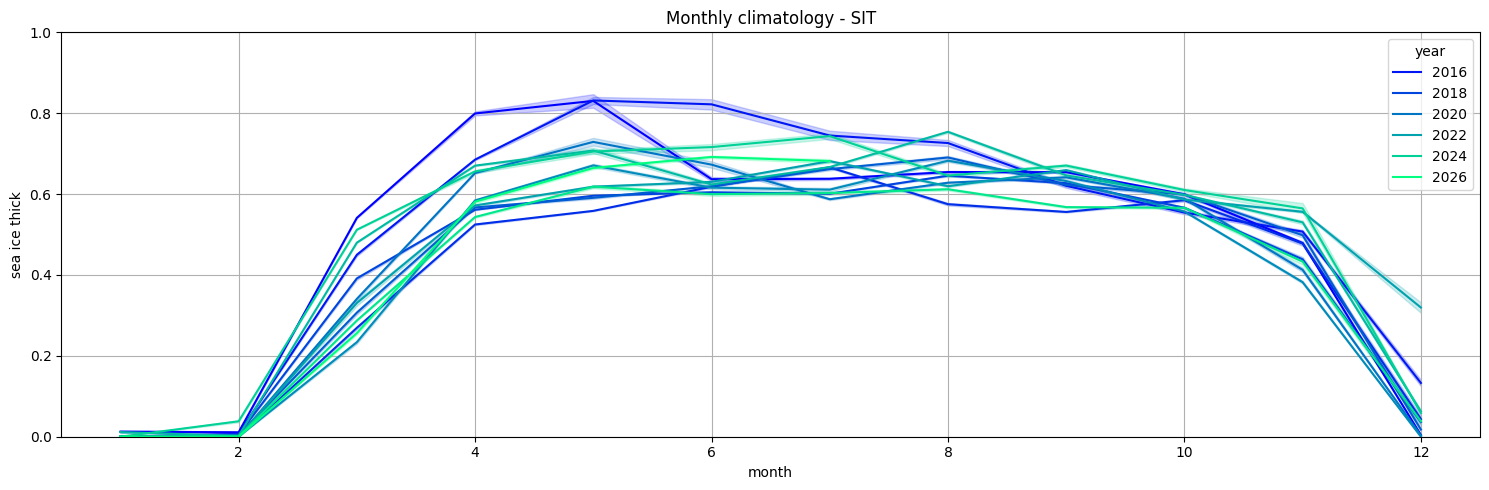

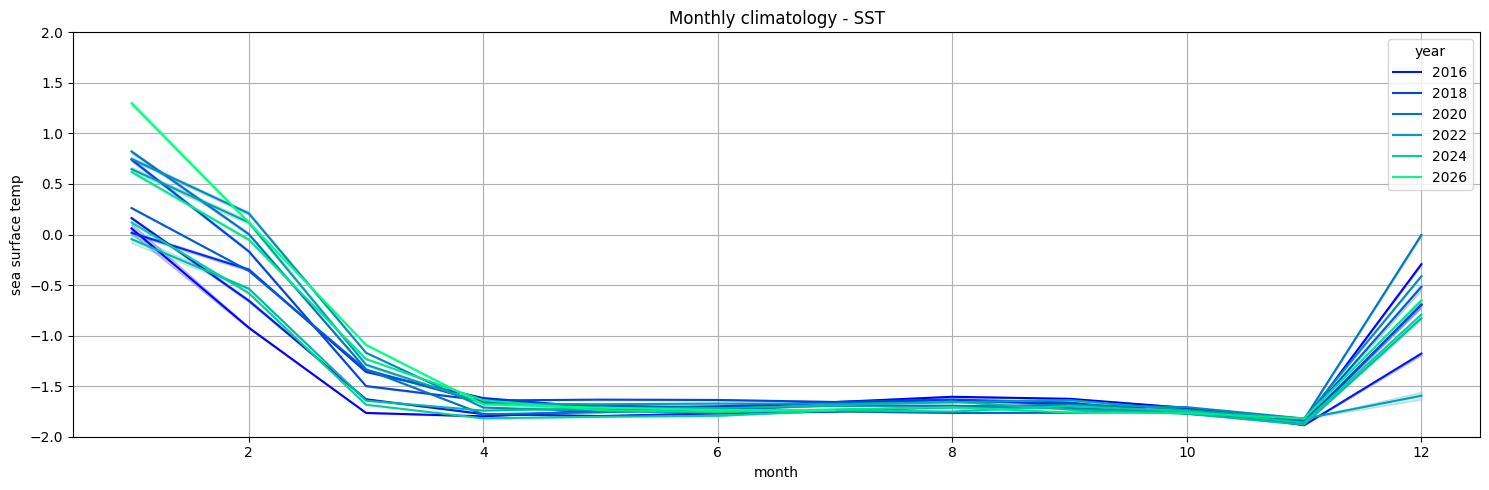

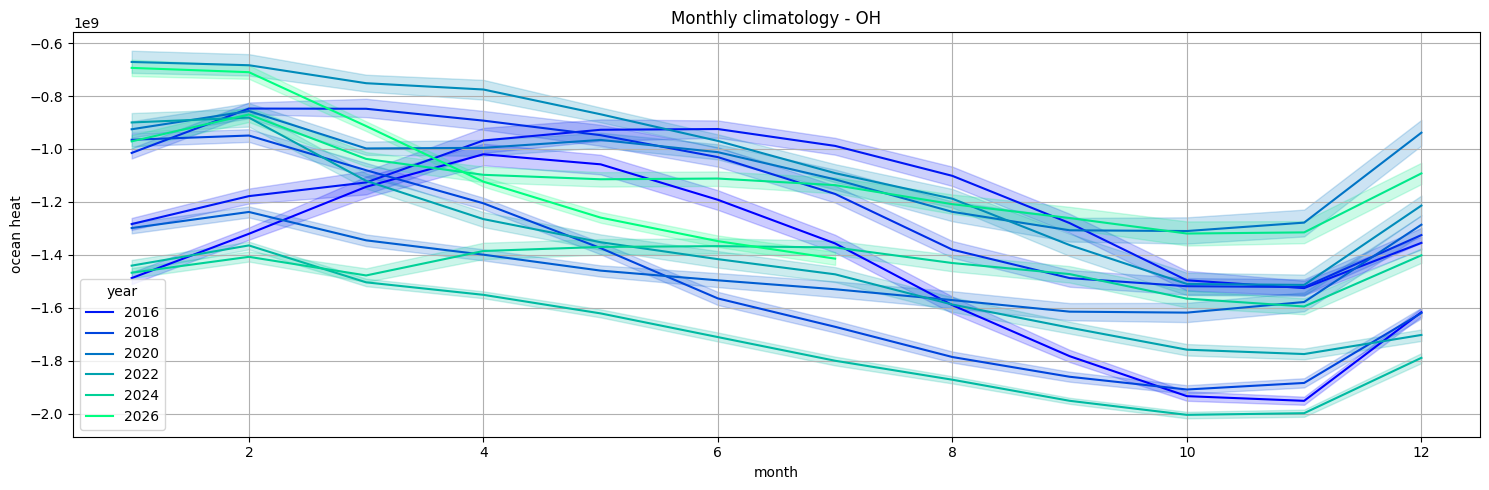

In [143]:
plt.figure(figsize=(15,5))
sns.lineplot(
    data=df,
    x='month',
    y='sea ice thick',
    hue='year',
    palette='winter'
)

plt.title("Monthly climatology - SIT")
plt.ylim(0, 1), plt.xlim(0.5,12.5)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,5))
sns.lineplot(
    data=df,
    x='month',
    y='sea surface temp',
    hue='year',
    palette='winter'
)

plt.title("Monthly climatology - SST")
plt.ylim(-2, 2), plt.xlim(0.5,12.5)
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(15,5))
sns.lineplot(
    data=df,
    x='month',
    y='ocean heat',
    hue='year',
    palette='winter'
)

plt.title("Monthly climatology - OH")
plt.xlim(0.5,12.5)
plt.grid(True)
plt.tight_layout()
plt.show()

**Annual variability**

In [144]:
df_annual = df.copy()
df_annual = df_annual[["year", "sea ice thick", "sea surface temp", "ocean heat"]].groupby(by="year").mean()

In [145]:
df_annual

,sea ice thick,sea surface temp,ocean heat
year,,,
2015,0.488394,-1.385440,-1.454065e+09
2016,0.506811,-1.448353,-1.179417e+09
2017,0.406208,-1.334917,-1.165326e+09
2018,0.422734,-1.258864,-1.488782e+09
2019,0.431427,-1.322682,-1.452566e+09
2020,0.438011,-1.205041,-1.078287e+09
2021,0.414167,-1.208249,-1.049932e+09
2022,0.464459,-1.305675,-1.408613e+09
2023,0.479444,-1.413036,-1.716696e+09


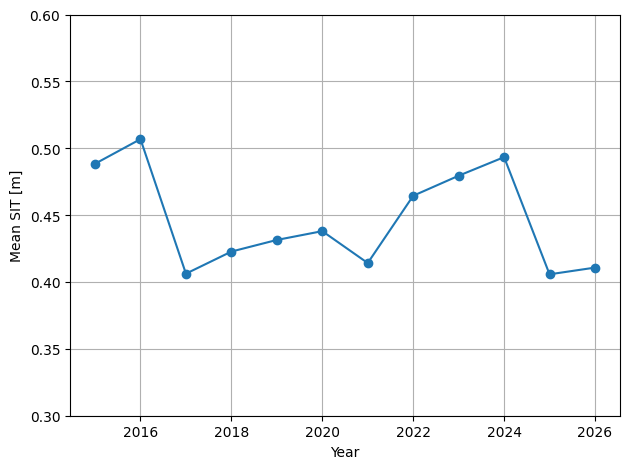

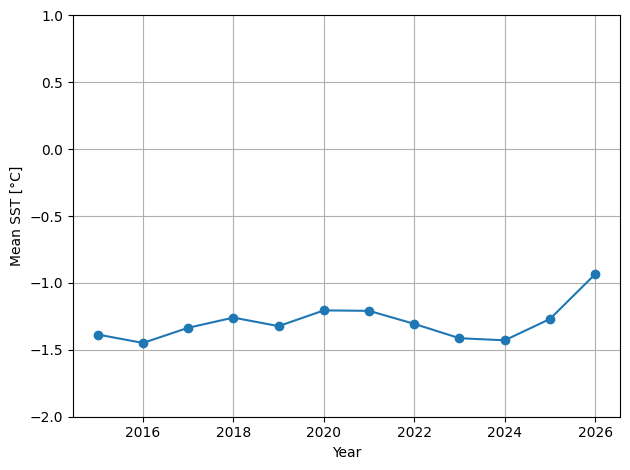

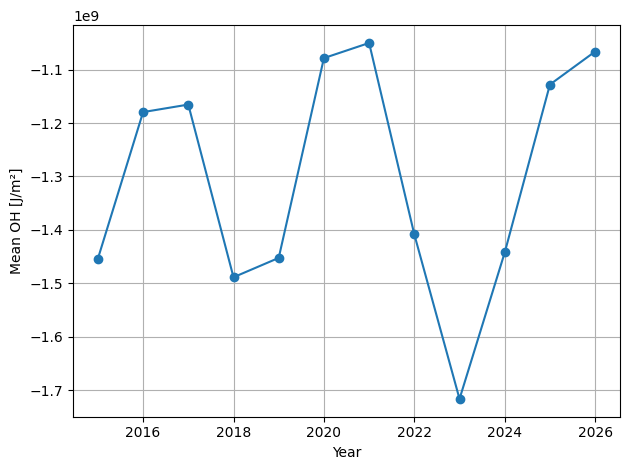

In [146]:
plt.figure()

plt.plot(df_annual.index,df_annual["sea ice thick"], '-o')
plt.xlabel("Year")
plt.ylabel("Mean SIT [m]")


plt.ylim(0.3, 0.6)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()

plt.plot(df_annual.index,df_annual["sea surface temp"], '-o')
plt.xlabel("Year")
plt.ylabel("Mean SST [°C]")


plt.ylim(-2, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()

plt.plot(df_annual.index,df_annual["ocean heat"], '-o')
plt.xlabel("Year")
plt.ylabel("Mean OH [J/m²]")


# plt.ylim(0.3, 0.6)
plt.grid(True)
plt.tight_layout()
plt.show()

**Seasonal variability**

In [147]:
df_season = (
    df[["year", "season", "sea ice thick", "sea surface temp", "ocean heat"]]
    .groupby(["year", "season"])
    .mean()
    .reset_index()
)

C:\Users\l.ruizlozano\AppData\Local\Temp\ipykernel_9352\1268489309.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["year", "season"])


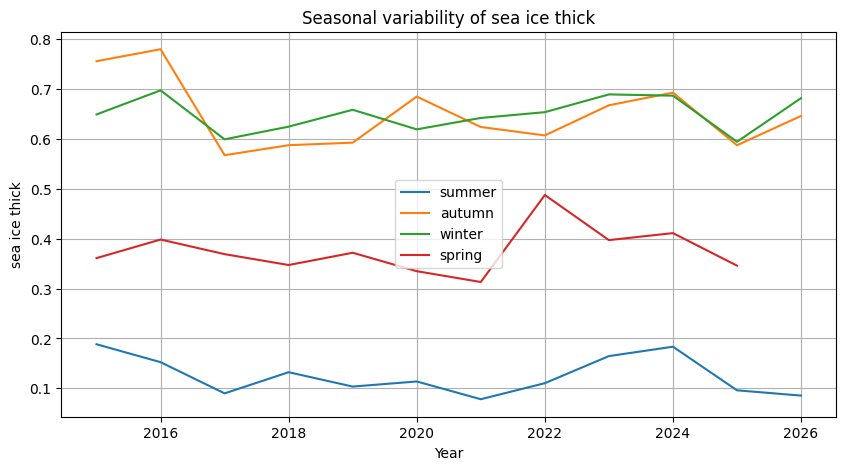

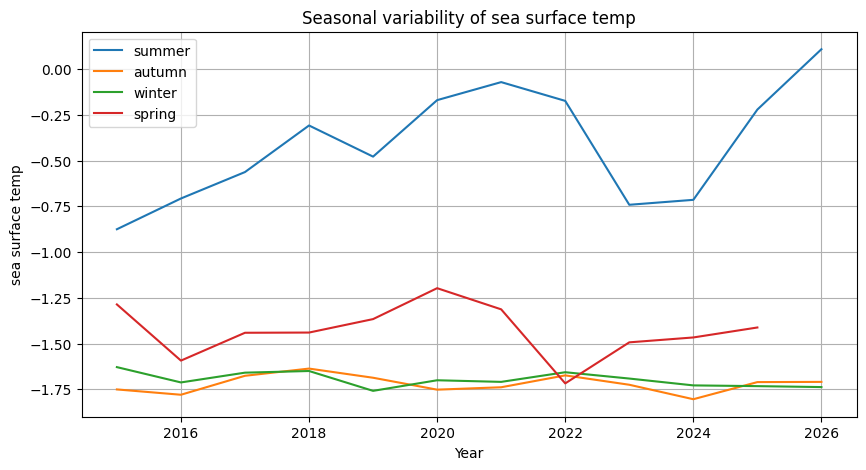

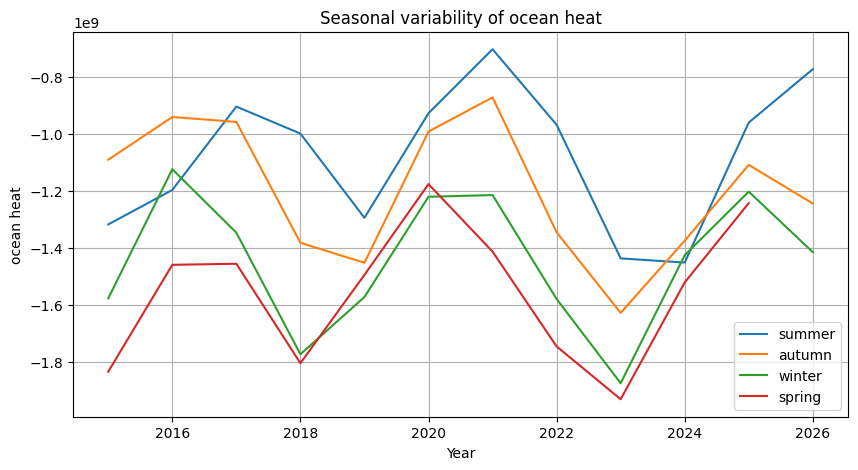

In [148]:
variables = ["sea ice thick", "sea surface temp", "ocean heat"]

for variable in variables:
    plt.figure(figsize=(10, 5))

    for season in df_season["season"].unique():
        data = df_season[df_season["season"] == season]
        plt.plot(data["year"], data[variable], label=season)

    plt.xlabel("Year")
    plt.ylabel(variable)
    plt.title(f"Seasonal variability of {variable}")
    plt.legend()
    plt.grid()
    plt.show()

**Anomalies**

An anomaly is simply:

observed value − expected value,
where the expected value is the climatological mean for that calendar month.

In [153]:
df_mean_month = df.groupby('month')[['sea ice thick', 'sea surface temp', 'ocean heat']].mean().reset_index()

In [159]:
df["sit_anomaly"] = ( 
                     df["sea ice thick"] - df["month"].map(df_mean_month.set_index("month")["sea ice thick"])
                    )

df["sst_anomaly"] = ( 
                     df["sea surface temp"] - df["month"].map(df_mean_month.set_index("month")["sea surface temp"])
                    )


df["oh_anomaly"] = ( 
                     df["ocean heat"] - df["month"].map(df_mean_month.set_index("month")["ocean heat"])
                    )

df.head()

,time,lon,lat,sea ice thick,sea surface temp,ocean heat,date,year,month,season,sit_anomaly,sst_anomaly,oh_anomaly
0,2015-01-16,174.0,-75.959343,0.000000,0.577931,-1.516163e+09,2015-01,2015,1,summer,-0.001999,0.123837,-422898944.0
1,2015-02-15,174.0,-75.959343,0.027109,-0.900055,-1.503449e+09,2015-02,2015,2,summer,0.021394,-0.636707,-477981504.0
2,2015-03-16,174.0,-75.959343,0.551697,-1.761970,-1.591986e+09,2015-03,2015,3,summer,0.185130,-0.342828,-479947776.0
3,2015-04-16,174.0,-75.959343,0.715715,-1.739402,-1.593836e+09,2015-04,2015,4,autumn,0.099325,-0.028285,-454046720.0
4,2015-05-16,174.0,-75.959343,0.627804,-1.664265,-1.764333e+09,2015-05,2015,5,autumn,-0.049006,0.062906,-571196288.0


- Time series of anomalies

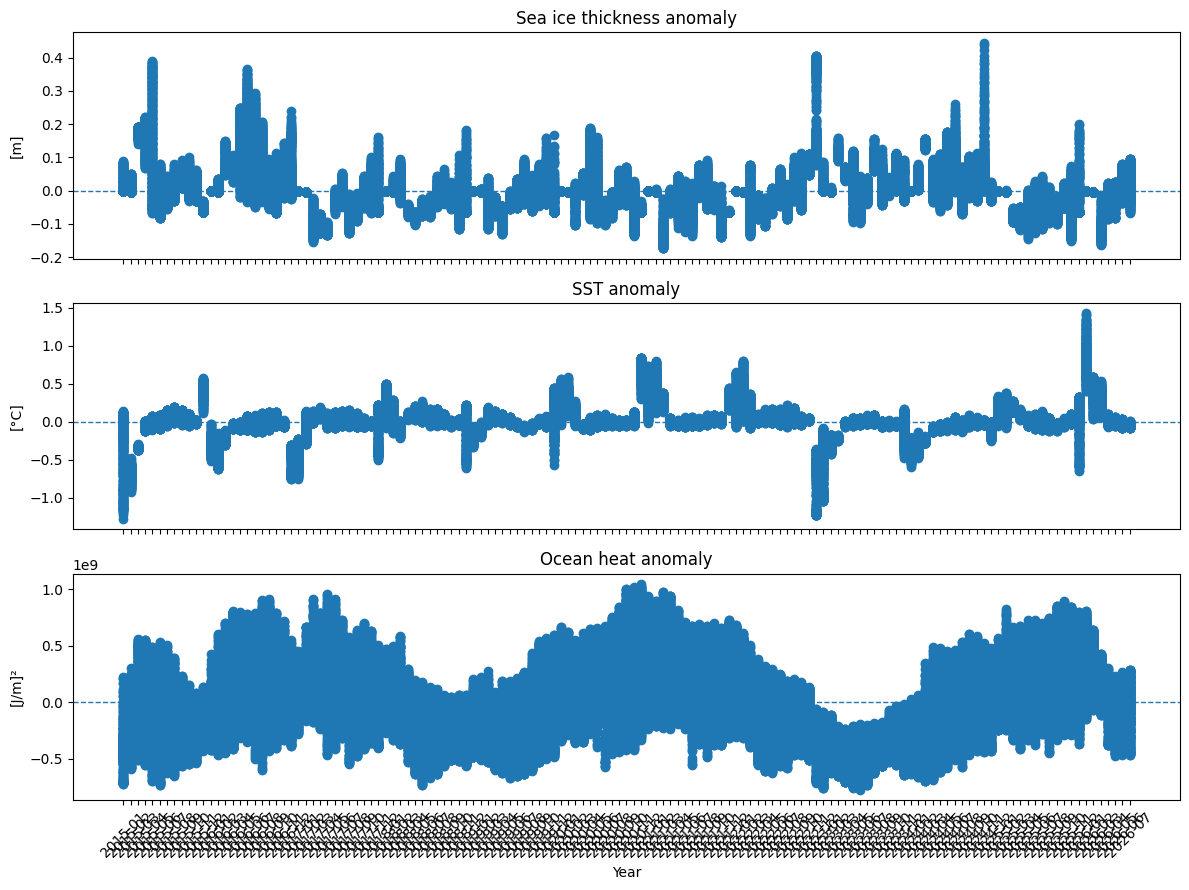

In [177]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

variables = [
    ("sit_anomaly", "Sea ice thickness anomaly", "[m]"),
    ("sst_anomaly", "SST anomaly", "[°C]"),
    ("oh_anomaly", "Ocean heat anomaly", "[J/m]²")
]

for ax, (col, title, unit) in zip(axes, variables):
    ax.scatter(df["date"], df[col])
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_ylabel(unit)
    ax.set_title(title)

axes[-1].set_xlabel("Year")
plt.xticks(

    rotation=45
)
plt.tight_layout()
plt.show()

- Heatmaps

In [190]:
df_monthly = (
    df.groupby(["year", "month"])
      .agg({
          "sit_anomaly": "mean",
          "sst_anomaly": "mean",
          "oh_anomaly": "mean"
      }).reset_index()
)

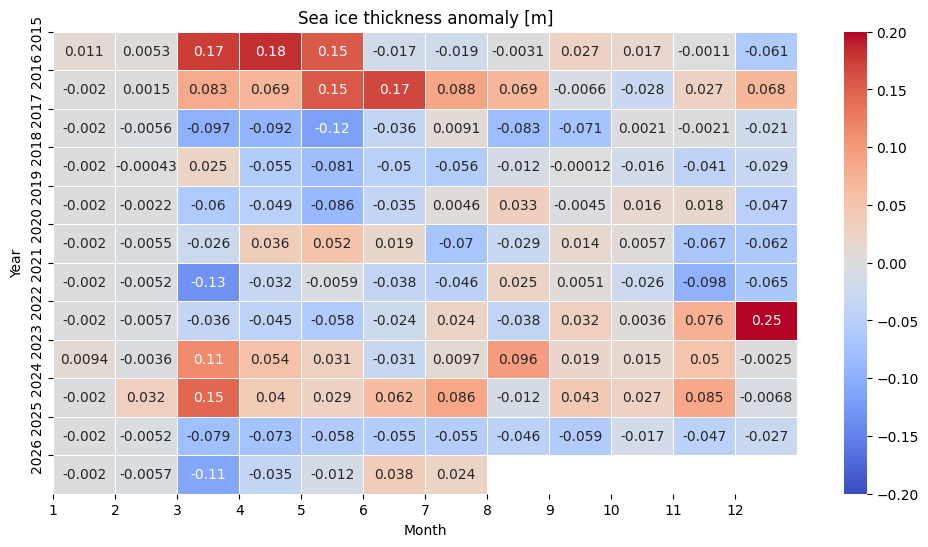

In [200]:
sit_heatmap = df_monthly.pivot(
    index="year",
    columns="month",
    values="sit_anomaly"
)

plt.figure(figsize=(12, 6))
sns.heatmap(sit_heatmap, annot=True, cmap="coolwarm", linewidths=0.5, vmin = -0.2, vmax = 0.2)
# plt.imshow(
#     sit_heatmap,
#     aspect="auto"
# )
plt.xticks(
    ticks=range(len(sit_heatmap.columns)),
    labels=sit_heatmap.columns
)
plt.yticks(
    ticks=range(len(sit_heatmap.index)),
    labels=sit_heatmap.index
)

plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Sea ice thickness anomaly [m]")

plt.show()

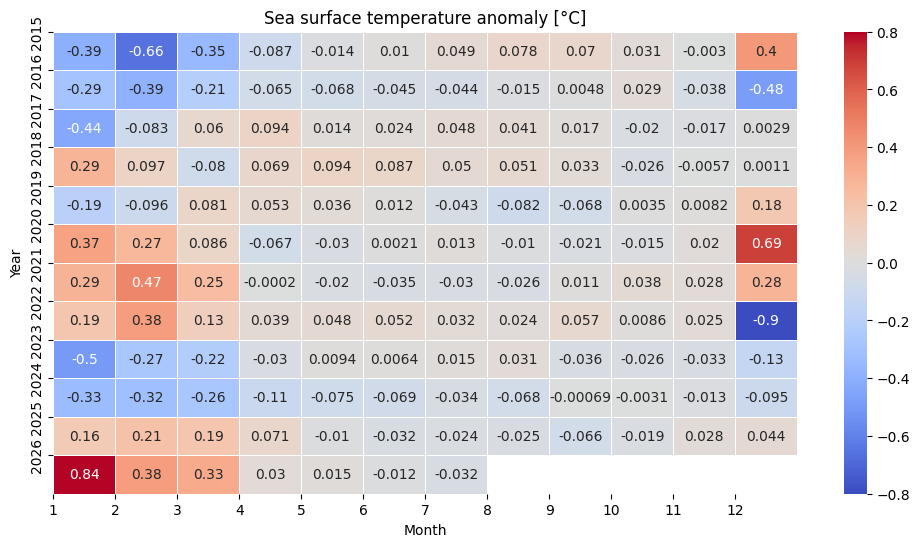

In [ ]:
sst_heatmap = df_monthly.pivot(
    index="year",
    columns="month",
    values="sst_anomaly"
)

plt.figure(figsize=(12, 6))
sns.heatmap(sst_heatmap, annot=True, cmap="coolwarm", linewidths=0.5, vmin = -0.8, vmax = 0.8)
# plt.imshow(
#     sit_heatmap,
#     aspect="auto"
# )
plt.xticks(
    ticks=range(len(sst_heatmap.columns)),
    labels=sst_heatmap.columns
)
plt.yticks(
    ticks=range(len(sst_heatmap.index)),
    labels=sst_heatmap.index
)

plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Sea surface temperature anomaly [°C]")

plt.show()

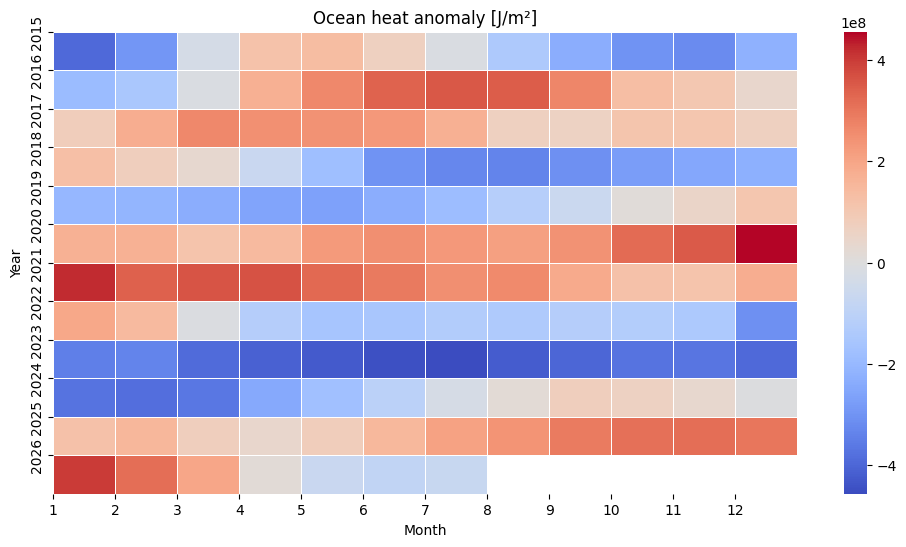

In [206]:
oh_heatmap = df_monthly.pivot(
    index="year",
    columns="month",
    values="oh_anomaly"
)

plt.figure(figsize=(12, 6))
sns.heatmap(oh_heatmap, annot=False, cmap="coolwarm", linewidths=0.5)
# plt.imshow(
#     sit_heatmap,
#     aspect="auto"
# )
plt.xticks(
    ticks=range(len(oh_heatmap.columns)),
    labels=oh_heatmap.columns
)
plt.yticks(
    ticks=range(len(oh_heatmap.index)),
    labels=oh_heatmap.index
)

plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Ocean heat anomaly [J/m²]")

plt.show()

- Correlation between variables

In [216]:
df.groupby("season")[["sit_anomaly", "sst_anomaly"]].corr()

C:\Users\l.ruizlozano\AppData\Local\Temp\ipykernel_9352\3605469421.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("season")[["sit_anomaly", "sst_anomaly"]].corr()


sit_anomaly  sst_anomaly
season                                      
summer sit_anomaly     1.000000    -0.394059
       sst_anomaly    -0.394059     1.000000
autumn sit_anomaly     1.000000    -0.649631
       sst_anomaly    -0.649631     1.000000
winter sit_anomaly     1.000000    -0.275319
       sst_anomaly    -0.275319     1.000000
spring sit_anomaly     1.000000    -0.721756
       sst_anomaly    -0.721756     1.000000

In [217]:
df.groupby("season")[["sit_anomaly", "oh_anomaly"]].corr()

C:\Users\l.ruizlozano\AppData\Local\Temp\ipykernel_9352\2057282029.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("season")[["sit_anomaly", "oh_anomaly"]].corr()


sit_anomaly  oh_anomaly
season                                     
summer sit_anomaly     1.000000   -0.294259
       oh_anomaly     -0.294259    1.000000
autumn sit_anomaly     1.000000    0.200265
       oh_anomaly      0.200265    1.000000
winter sit_anomaly     1.000000   -0.015817
       oh_anomaly     -0.015817    1.000000
spring sit_anomaly     1.000000   -0.334285
       oh_anomaly     -0.334285    1.000000

## Machine learning - Anomalies survey

Quick test to compare with the climatology anomalies definition

To do that, we use the Isolation Forest model from scikit-learn to detect outliers in the anomalies values. 

In [218]:
from sklearn.ensemble import IsolationForest

In [238]:
X =df[["sit_anomaly"]]
model = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
model.fit(X)
df["IF_prediction"] = model.predict(X)
outliers = df[df["IF_prediction"] == -1]

In [240]:
outliers[
    ["year", "month", "sit_anomaly", "IF_prediction"]
].sort_values(["sit_anomaly"])

,year,month,sit_anomaly,IF_prediction
37604,2021,3,-0.173639,-1
35102,2021,3,-0.173457,-1
36353,2021,3,-0.172840,-1
33851,2021,3,-0.172726,-1
32600,2021,3,-0.171630,-1
...,...,...,...,...
37903,2022,12,0.404091,-1
37625,2022,12,0.404096,-1
35146,2024,11,0.422897,-1
36397,2024,11,0.436399,-1


In [243]:
X =df[[ 'sit_anomaly', 'sst_anomaly',
       'oh_anomaly',]]
model = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
model.fit(X)
df["IF_prediction"] = model.predict(X)
outliers = df[df["IF_prediction"] == -1]

outliers[
    ["year", "month", 'sit_anomaly', 'sst_anomaly',
       'oh_anomaly', "IF_prediction"]
].sort_values(["sit_anomaly","sst_anomaly", "oh_anomaly"])

,year,month,sit_anomaly,sst_anomaly,oh_anomaly,IF_prediction
33573,2021,3,-0.154358,0.183760,837643264.0,-1
32322,2021,3,-0.153952,0.183355,876657152.0,-1
31071,2021,3,-0.153055,0.188547,894611456.0,-1
33712,2021,3,-0.153034,0.158702,967764224.0,-1
34963,2021,3,-0.152834,0.157414,950977792.0,-1
...,...,...,...,...,...,...
37903,2022,12,0.404091,-1.220473,-683589120.0,-1
37625,2022,12,0.404096,-1.221725,-662453120.0,-1
35146,2024,11,0.422897,0.023376,-414508288.0,-1
36397,2024,11,0.436399,0.025667,-414866176.0,-1


## Discussions

**Key findings**

- Antarctic Ross Sea sea-ice thickness exhibits a strong seasonal cycle, with minimum thickness during austral summer and maximum thickness during winter.
- Sea surface temperature shows an opposite seasonal behaviour, with warmer conditions occurring during periods of reduced sea-ice thickness.
- Interannual variability is substantial, but no clear monotonic trend in sea-ice thickness is observed over 2015–2026.
- Recent years show notable SST anomalies, particularly positive anomalies during austral summer 2025–2026. However, the short study period and incomplete 2026 data do not allow a robust long-term warming trend to be established.
- SIT anomalies also show substantial interannual variability, including periods of both positive and negative departures from the monthly climatology.
- SIT and SST anomalies exhibit a moderate negative correlation overall (r=−0.42), indicating that warmer-than-average surface waters tend to coincide with thinner-than-average sea ice.
- This relationship is strongly season-dependent, with stronger negative correlations in spring (r=−0.72) and autumn (r=−0.65), and a weaker relationship in winter (r=−0.28).
- In contrast, the relationship between ocean heat content and SIT is weaker and less consistent across seasons, with correlations ranging from approximately −0.33 to +0.20.
- These results suggest that SST is more strongly associated with SIT variability than OHC, although this does not imply a causal relationship.
- A preliminary Isolation Forest analysis identified March 2021 as a potential multivariate outlier, consistently characterized by below-average SIT (~−0.15 m) combined with above-average SST (~+0.18 °C) and OHC, supporting the anomaly-based analysis and highlighting this period as a candidate for further investigation.